In [285]:
#Install and import
!pip install yfinance hmmlearn pandas numpy matplotlib seaborn

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Download the necessary data.

In [287]:
vix = yf.download("^VIX", start="2000-01-01", auto_adjust="True")
spy = yf.download("SPY", start="2000-01-01", auto_adjust="True")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


## Grab the necessary columns, clean, and calculate our log returns for SPY

In [289]:
spy_close = spy["Close"]
vix_close = vix["Close"].dropna()

log_returns = np.log(spy_close / spy_close.shift(1)).dropna()

## Data Overview

### SPY Log Returns (2000–Present)
- **Mean**: 0.0003 — small positive drift, reflects long-term upward trend
- **Std**: 0.012 — ~1.2% average daily volatility
- **Min**: -0.116 — worst single day crash (likely March 2020 or Oct 2008)
- **Max**: 0.136 — largest single day gain (likely post-crash recovery)

### VIX (2000–Present)
- **Mean**: 19.8 — historically anything below 20 is considered calm
- **Min**: 9.14 — extremely low fear, deep bull market conditions
- **Max**: 82.69 — COVID March 2020, peak panic
- **75th percentile**: 23.2 — 75% of days VIX was below 23, so above this is elevated fear

In [291]:
print(log_returns.describe())
print()
print(vix_close.describe())

Ticker          SPY
count   6602.000000
mean       0.000299
std        0.012192
min       -0.115887
25%       -0.004615
50%        0.000681
75%        0.005966
max        0.135578

Ticker         ^VIX
count   6603.000000
mean      19.845946
std        8.338258
min        9.140000
25%       14.020000
50%       17.809999
75%       23.245000
max       82.690002


## Plotting SPY & VIX Closing Prices

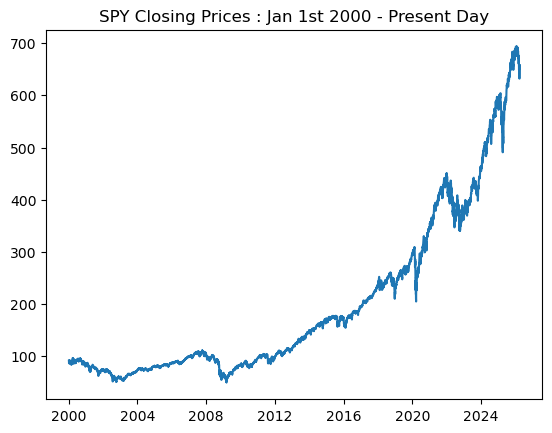

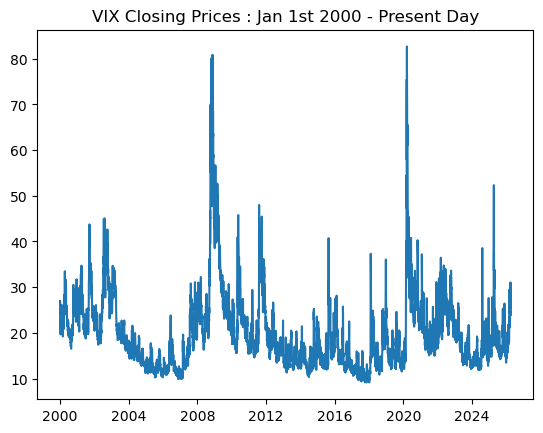

In [293]:
plt.plot(spy_close)
plt.title('SPY Closing Prices : Jan 1st 2000 - Present Day')
plt.show()

plt.plot(vix_close)
plt.title('VIX Closing Prices : Jan 1st 2000 - Present Day')
plt.show()

## Create / Clean the Data Frame

In [295]:
df = pd.concat([log_returns, vix_close], axis=1)
df_cleaned = df.dropna()
df_cleaned.shape

(6602, 2)

## Normalizing Values

Because the values of VIX are much higher than the ones in SPY, here we standardize the values to be centered around a mean of 0 and a standard deviation of 1

In [297]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_cleaned)
print(df_scaled)

[[-3.29655947  0.85927591]
 [ 0.1220266   0.78731689]
 [-1.35346049  0.70576335]
 ...
 [ 0.59116814  0.5630449 ]
 [ 0.04929822  0.4826907 ]
 [ 0.25016633  0.55345015]]


In [298]:
from hmmlearn import hmm
import collections

model = hmm.GaussianHMM(n_components=3, covariance_type="full", n_iter=100, random_state=42)

model.fit(df_scaled)
states = model.predict(df_scaled)

print(states)
print(collections.Counter(states))
print(model.means_)

[2 2 2 ... 2 2 2]
Counter({0: 2672, 1: 2423, 2: 1507})
[[-0.0014732  -0.06894189]
 [ 0.04899533 -0.7969518 ]
 [-0.07440086  1.36993329]]


(6602, 1)
['red', 'red', 'red', 'red', 'green']


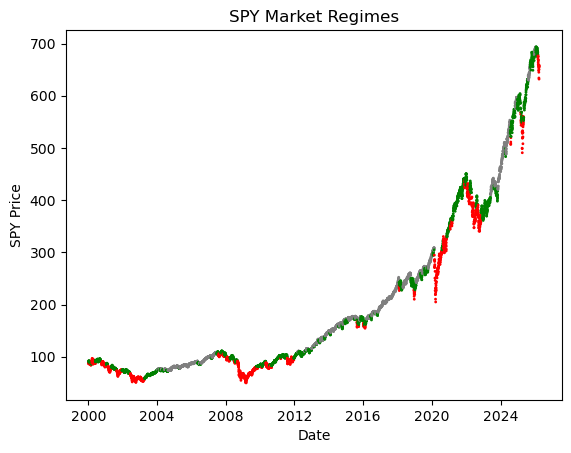

Ticker,SPY,^VIX
Date,,
2000-01-04,-0.039891,27.010000
2000-01-05,0.001787,26.410000
2000-01-06,-0.016202,25.730000
2000-01-07,0.056452,21.719999
2000-01-10,0.003425,21.709999
...,...,...
2026-03-30,-0.003349,30.610001
2026-03-31,0.028653,25.250000
2026-04-01,0.007506,24.540001


In [299]:
spy_aligned = spy_close.loc[df_cleaned.index]
print(spy_aligned.shape)

colors = [{0: "green", 1: "gray", 2: "red"}[s] for s in states]
print(colors[:5])

plt.scatter(df_cleaned.index, spy_aligned, c=colors, s=1)
plt.title("SPY Market Regimes")
plt.xlabel("Date")
plt.ylabel("SPY Price")
plt.show()

df_cleaned

# Feature Engineering

Discretized Log returns: [-∞, -0.0046, 0.0060, ∞]

Decretized VIX: [-∞, 14.01, 23.20, ∞]

Labels: ['low', 'medium', 'high']

dataframe with these five columns — log_return, vix, regime, return_bin, vix_bin.

In [301]:
log_return = df_cleaned['SPY']
vix = df_cleaned['^VIX']
regime = pd.Categorical.from_codes(states, categories=["bull", "sideways", "bear"])
return_bin = pd.cut(df_cleaned['SPY'], bins=[-np.inf, -0.0046, 0.0060, np.inf], labels=["low", "medium", "high"])
vix_bin = pd.cut(df_cleaned['^VIX'], bins=[-np.inf, 14.01, 23.20, np.inf], labels=["low", "neutral", "high"])

df_q_info = pd.DataFrame({
    'Log Return': log_return,
    'Volatility' : vix,
    'Regime': regime,
    'Returns (Discretized)': return_bin,
    'Volatility (Discretized)': vix_bin,
})

df_q_info

,Log Return,Volatility,Regime,Returns (Discretized),Volatility (Discretized)
Date,,,,,
2000-01-04,-0.039891,27.010000,bear,low,high
2000-01-05,0.001787,26.410000,bear,medium,high
2000-01-06,-0.016202,25.730000,bear,low,high
2000-01-07,0.056452,21.719999,bear,high,neutral
2000-01-10,0.003425,21.709999,bull,medium,neutral
...,...,...,...,...,...
2026-03-30,-0.003349,30.610001,bear,medium,high
2026-03-31,0.028653,25.250000,bear,high,high
2026-04-01,0.007506,24.540001,bear,high,high
